<a href="https://colab.research.google.com/github/mtchandick/Tempo/blob/main/%E8%B7%A8%E5%B8%82%E5%A0%B4%E8%B2%A1%E5%A0%B1%E7%8F%BE%E9%87%91%E6%B5%81%E5%88%86%E6%9E%90%E5%99%A8V2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

正在深度分析: STM...
正在深度分析: ONDS...
正在深度分析: KO...
正在深度分析: CL...
正在深度分析: ZS...
正在深度分析: PANW...
正在深度分析: 0916.HK...
正在深度分析: 8035.HK...
正在深度分析: 0924.HK...
正在深度分析: 2738.HK...
正在深度分析: 2729.HK...
正在深度分析: 8460.HK...
正在深度分析: 2726.HK...
正在深度分析: 8030.HK...
正在深度分析: 0493.HK...
正在深度分析: 2700.HK...
正在深度分析: 2699.HK...
正在深度分析: 8027.HK...
正在深度分析: 0496.HK...
正在深度分析: 0110.HK...
正在深度分析: 2685.HK...
正在深度分析: 0500.HK...
正在深度分析: 8452.HK...
正在深度分析: 8430.HK...
正在深度分析: 0505.HK...
正在深度分析: 0200.HK...
正在深度分析: 8006.HK...
正在深度分析: 2651.HK...
正在深度分析: 0205.HK...
正在深度分析: 6988.HK...
正在深度分析: 8428.HK...
正在深度分析: 8419.HK...
正在深度分析: 8406.HK...
正在深度分析: 0990.HK...
正在深度分析: 8391.HK...
正在深度分析: 8385.HK...
正在深度分析: 0994.HK...
正在深度分析: 2630.HK...
警告: 2630.HK 數據不足或 Ticker 無效，跳過分析。
正在深度分析: 2623.HK...
正在深度分析: 1792.HK...
正在深度分析: 2617.HK...
正在深度分析: 1003.HK...
正在深度分析: 2613.HK...
正在深度分析: 1011.HK...
正在深度分析: 1020.HK...
正在深度分析: 0527.HK...
正在深度分析: 2609.HK...
正在深度分析: 2608.HK...
正在深度分析: 1026.HK...
正在深度分析: 2603.HK...
正在深度分析: 2597.HK...
正在深度分析: 9981.HK...
正在深

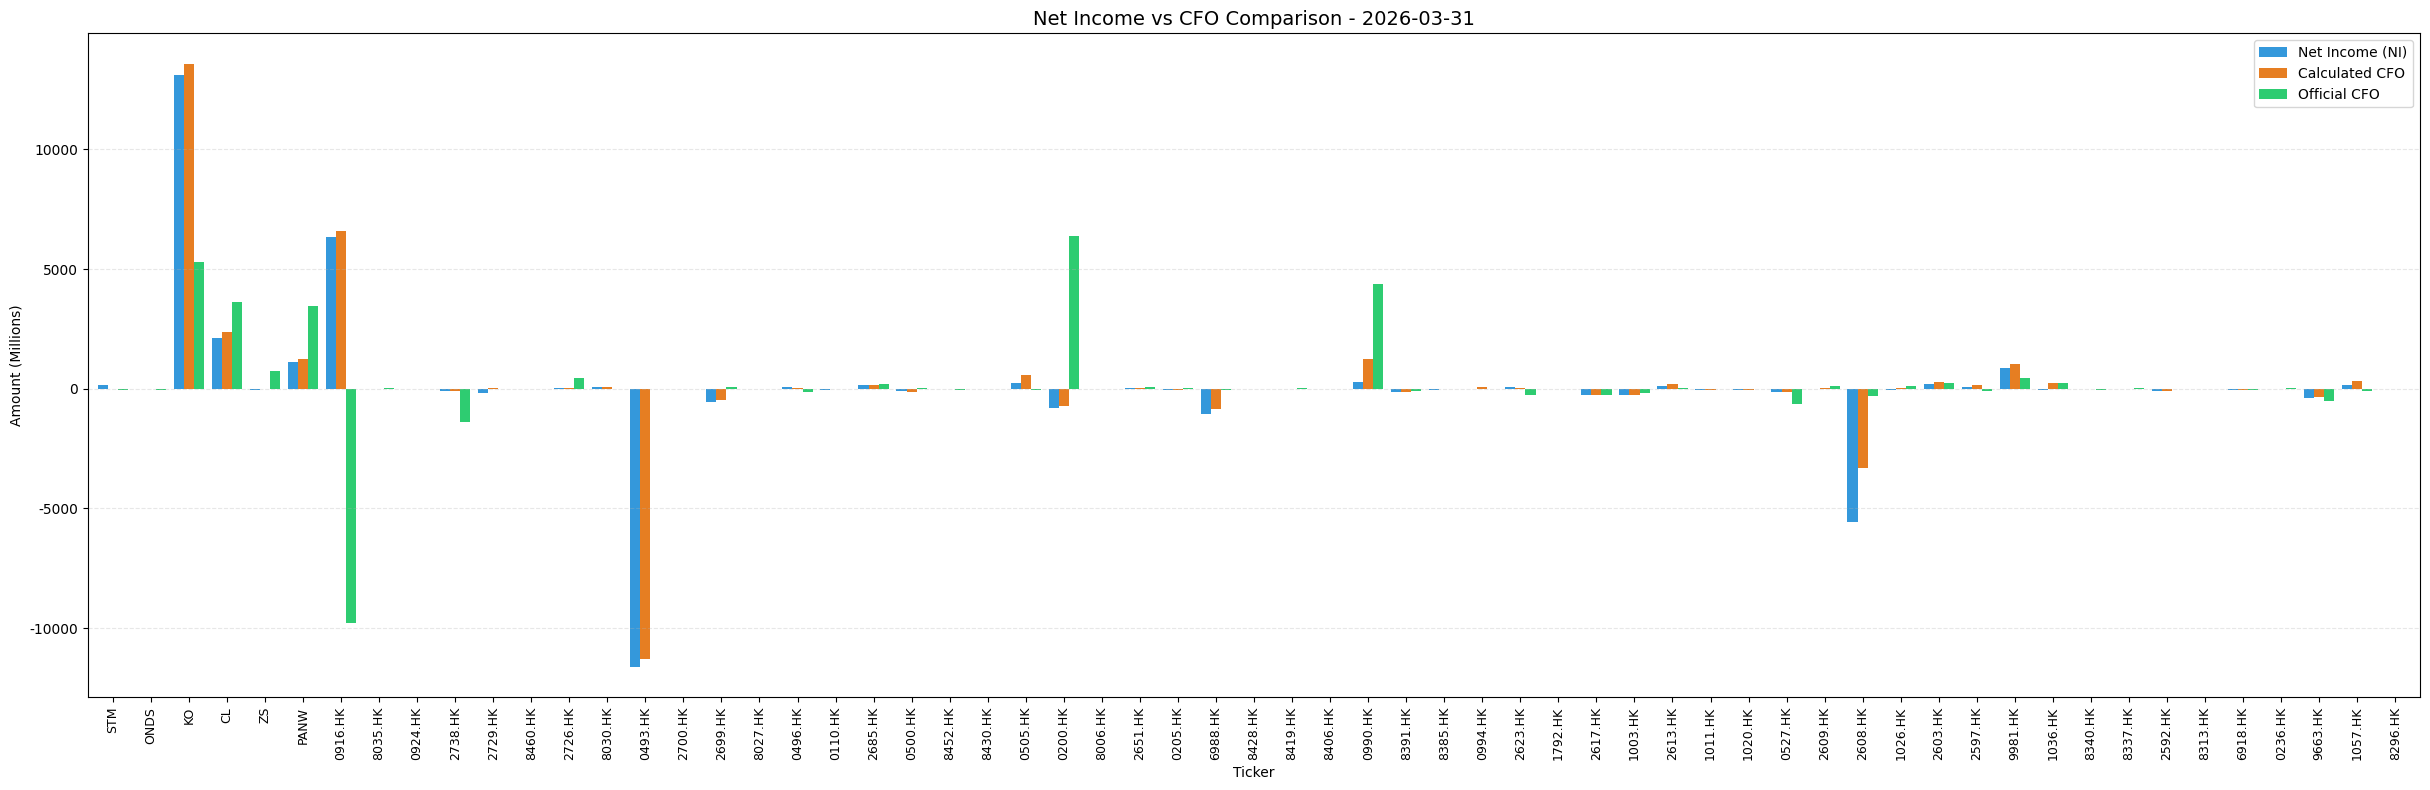

In [1]:
import sys

# 環境檢查：確保所有必要的庫都已安裝
try:
    import yfinance as yf
    import pandas as pd
    import numpy as np
    import matplotlib.pyplot as plt
    from matplotlib import font_manager
except ImportError as e:
    print(f"錯誤: 缺少必要的模組 '{e.name}'。")
    print("請執行以下指令安裝: pip install yfinance pandas matplotlib numpy")
    sys.exit(1)

from datetime import datetime

class FinancialAnalyzerV2:
    def __init__(self, tickers):
        """
        初始化分析器，傳入 Ticker 清單
        """
        self.tickers = tickers
        self.results = {}
        self.plot_data = []

    def get_industry_category(self, ticker_obj):
        """
        根據產業分類自動匹配計算模板 (CFA 專家邏輯)
        """
        try:
            info = ticker_obj.info
            sector = info.get('sector', '')
            industry = info.get('industry', '')
            # 識別銀行與金融業 (金融業現金流邏輯特殊)
            if 'Bank' in industry or 'Financial' in sector:
                return 'Banking'
            # 識別房地產信託
            elif 'REIT' in industry:
                return 'REIT'
            # 其他一般工業與科技業
            else:
                return 'General'
        except:
            return 'General'

    def run_analysis(self):
        """
        執行全自動化財報抓取與現金流還原計算
        """
        for t in self.tickers:
            print(f"正在深度分析: {t}...")
            try:
                tk = yf.Ticker(t)
                # 抓取三大報表
                is_stmt = tk.financials     # 損益表
                bs_stmt = tk.balance_sheet   # 資產負債表
                cf_stmt = tk.cashflow        # 官方現金流量表

                if is_stmt.empty or bs_stmt.empty or bs_stmt.shape[1] < 2:
                    print(f"警告: {t} 數據不足或 Ticker 無效，跳過分析。")
                    continue

                category = self.get_industry_category(tk)

                # 數據提取
                is_curr = is_stmt.iloc[:, 0]
                bs_curr = bs_stmt.iloc[:, 0]
                bs_prev = bs_stmt.iloc[:, 1]

                net_income = is_curr.get('Net Income', is_curr.get('Net Income Common Stockholders', 0))
                actual_cfo = cf_stmt.iloc[0, 0] if not cf_stmt.empty else 0

                # --- 核心邏輯計算 (CFA 專業模型) ---
                if category == 'Banking':
                    provisions = is_curr.get('Provision For Loan Losses', 0)
                    loans_curr = bs_curr.get('Net Loans', bs_curr.get('Loans And Advances', 0))
                    loans_prev = bs_prev.get('Net Loans', bs_prev.get('Loans And Advances', 0))
                    depo_curr = bs_curr.get('Total Deposits', bs_curr.get('Customer Deposits', 0))
                    depo_prev = bs_prev.get('Total Deposits', bs_prev.get('Customer Deposits', 0))

                    delta_loans = -(loans_curr - loans_prev)
                    delta_deposits = (depo_curr - depo_prev)
                    calc_cfo = net_income + provisions + delta_loans + delta_deposits
                else:
                    da = is_curr.get('Depreciation And Amortization', is_curr.get('Depreciation & Amortization', 0))
                    delta_ar = -(bs_curr.get('Net Receivables', 0) - bs_prev.get('Net Receivables', 0))
                    delta_inv = -(bs_curr.get('Inventory', 0) - bs_prev.get('Inventory', 0))
                    delta_ap = (bs_curr.get('Accounts Payable', 0) - bs_prev.get('Accounts Payable', 0))
                    calc_cfo = net_income + da + delta_ar + delta_inv + delta_ap

                # 存儲結果 (百萬)
                self.results[t] = {
                    "Category": category,
                    "NetIncome_M": round(net_income / 1e6, 2),
                    "CalcCFO_M": round(calc_cfo / 1e6, 2),
                    "ActualCFO_M": round(actual_cfo / 1e6, 2),
                    "Diff_%": round(abs((calc_cfo - actual_cfo)/actual_cfo)*100, 2) if actual_cfo != 0 else 0
                }

                self.plot_data.append({
                    'Ticker': t,
                    'Net Income': net_income / 1e6,
                    'Calculated CFO': calc_cfo / 1e6,
                    'Actual CFO': actual_cfo / 1e6
                })

            except Exception as e:
                print(f"分析 {t} 時發生錯誤: {e}")

        return pd.DataFrame(self.results).T

    def visualize(self):
        """
        生成圖表，自動處理字體缺失問題並優化大批量數據顯示
        """
        if not self.plot_data:
            print("無數據可供視覺化。")
            return

        df_plot = pd.DataFrame(self.plot_data)
        df_plot.set_index('Ticker', inplace=True)

        # --- 自動選擇可用字體 ---
        available_fonts = [f.name for f in font_manager.fontManager.ttflist]
        chinese_fonts = ['Arial Unicode MS', 'Microsoft YaHei', 'SimHei', 'PingFang HK', 'Heiti TC']

        selected_font = None
        for f in chinese_fonts:
            if any(f in af for af in available_fonts):
                selected_font = f
                break

        if selected_font:
            plt.rcParams['font.sans-serif'] = [selected_font]
            title = f"盈餘與現金流對比分析 - {datetime.now().strftime('%Y-%m-%d')}"
            ylabel = "金額 (百萬)"
            legend = ["淨利 (NI)", "模型推算 CFO", "官方公佈 CFO"]
        else:
            title = f"Net Income vs CFO Comparison - {datetime.now().strftime('%Y-%m-%d')}"
            ylabel = "Amount (Millions)"
            legend = ["Net Income (NI)", "Calculated CFO", "Official CFO"]

        plt.rcParams['axes.unicode_minus'] = False

        # 增加畫布寬度以適應大量 Ticker
        fig_width = max(15, len(self.plot_data) * 0.4)
        ax = df_plot.plot(kind='bar', figsize=(fig_width, 8), width=0.8, color=['#3498db', '#e67e22', '#2ecc71'])
        plt.title(title, fontsize=14)
        plt.ylabel(ylabel)
        plt.xticks(rotation=90, fontsize=9) # 90度旋轉標籤
        plt.legend(legend)
        plt.grid(axis='y', linestyle='--', alpha=0.3)
        plt.tight_layout()
        plt.show()

# 更新後的 Ticker 清單
all_tickers = [
    'STM', 'ONDS', 'KO', 'CL', 'ZS', 'PANW',
    '0916.HK', '8035.HK', '0924.HK', '2738.HK', '2729.HK', '8460.HK',
    '2726.HK', '8030.HK', '0493.HK', '2700.HK', '2699.HK',
    '8027.HK', '0496.HK', '0110.HK', '2685.HK', '0500.HK',
    '8452.HK', '8430.HK', '0505.HK', '0200.HK', '8006.HK',
    '2651.HK', '0205.HK', '6988.HK', '8428.HK', '8419.HK',
    '8406.HK', '0990.HK', '8391.HK', '8385.HK', '0994.HK',
    '2630.HK', '2623.HK', '1792.HK', '2617.HK', '1003.HK',
    '2613.HK', '1011.HK', '1020.HK', '0527.HK', '2609.HK',
    '2608.HK', '1026.HK', '2603.HK', '2597.HK', '9981.HK',
    '1036.HK', '8340.HK', '8337.HK', '2592.HK', '8313.HK',
    '6918.HK', '0236.HK', '9663.HK', '1057.HK', '8296.HK'
]

if __name__ == "__main__":
    analyzer = FinancialAnalyzerV2(all_tickers)
    report = analyzer.run_analysis()
    print("\n" + "="*60)
    print(f" 批量分析報告 (共 {len(all_tickers)} 個 Tickers) ")
    print("="*60)
    print(report.to_string())
    print("="*60)
    analyzer.visualize()